In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(r"D:\DATA SCIENCE\Content Monetization Modeler\youtube_ad_revenue_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (122400, 12)


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (122400, 12)

Column data types:
video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

Missing values in each column:
video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

Duplicate rows:
2400


In [4]:
# Number of rows before removing duplicates
print("Before removing duplicates:", df.shape)

# Remove duplicate rows
df = df.drop_duplicates()

# Number of rows after removing duplicates
print("After removing duplicates:", df.shape)

# Verify duplicates
print("Remaining duplicates:", df.duplicated().sum())

Before removing duplicates: (122400, 12)
After removing duplicates: (120000, 12)
Remaining duplicates: 0


In [5]:
# Numeric columns that contain missing values
missing_columns = ["likes", "comments", "watch_time_minutes"]

# Fill missing values with each column's median
for column in missing_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
    print(f"{column}: missing values filled with median = {median_value:.2f}")

# Verify that no missing values remain
print("\nMissing values after filling:")
print(df[missing_columns].isnull().sum())

likes: missing values filled with median = 1102.00
comments: missing values filled with median = 274.00
watch_time_minutes: missing values filled with median = 37522.22

Missing values after filling:
likes                 0
comments              0
watch_time_minutes    0
dtype: int64


In [6]:
# Convert date column from text to datetime format
df["date"] = pd.to_datetime(df["date"])

# Create useful features from date
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

# Check the result
df[["date", "month", "day_of_week"]].head()

,date,month,day_of_week
0,2024-09-24 10:50:40.993199,9,Tuesday
1,2024-09-22 10:50:40.993199,9,Sunday
2,2024-11-21 10:50:40.993199,11,Thursday
3,2025-01-28 10:50:40.993199,1,Tuesday
4,2025-04-28 10:50:40.993199,4,Monday


In [7]:
# Engagement rate = (likes + comments) / views
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["views"]

# Likes received for each view
df["likes_per_view"] = df["likes"] / df["views"]

# Comments received for each view
df["comments_per_view"] = df["comments"] / df["views"]

# Watch time generated per view
df["watch_minutes_per_view"] = df["watch_time_minutes"] / df["views"]

# Display the newly created features
df[[
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "engagement_rate",
    "likes_per_view",
    "comments_per_view",
    "watch_minutes_per_view"
]].head()

,views,likes,comments,watch_time_minutes,engagement_rate,likes_per_view,comments_per_view,watch_minutes_per_view
0,9936,1221.0,320.0,26497.214184,0.155093,0.122886,0.032206,2.666789
1,10017,642.0,346.0,15209.747445,0.098632,0.064091,0.034541,1.518393
2,10097,1979.0,187.0,57332.658498,0.214519,0.195999,0.018520,5.678187
3,10034,1191.0,242.0,31334.517771,0.142814,0.118696,0.024118,3.122834
4,9889,1858.0,477.0,15665.666434,0.236121,0.187886,0.048235,1.584151


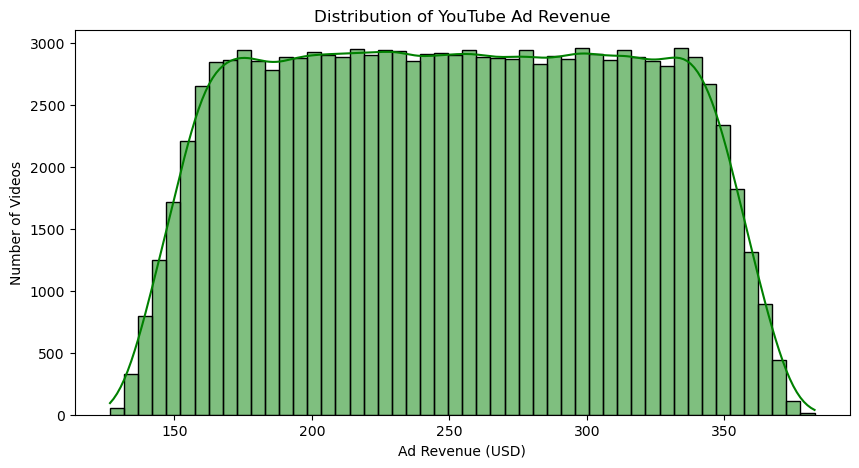

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(df["ad_revenue_usd"], bins=50, kde=True, color="green")

plt.title("Distribution of YouTube Ad Revenue")
plt.xlabel("Ad Revenue (USD)")
plt.ylabel("Number of Videos")

plt.show()

Insight:
The ad revenue values range approximately from usd 125 to  usd 380.
The distribution is relatively balanced, with most records spread between
usd 170 and  usd 340. No severe outliers are visible in the target variable.

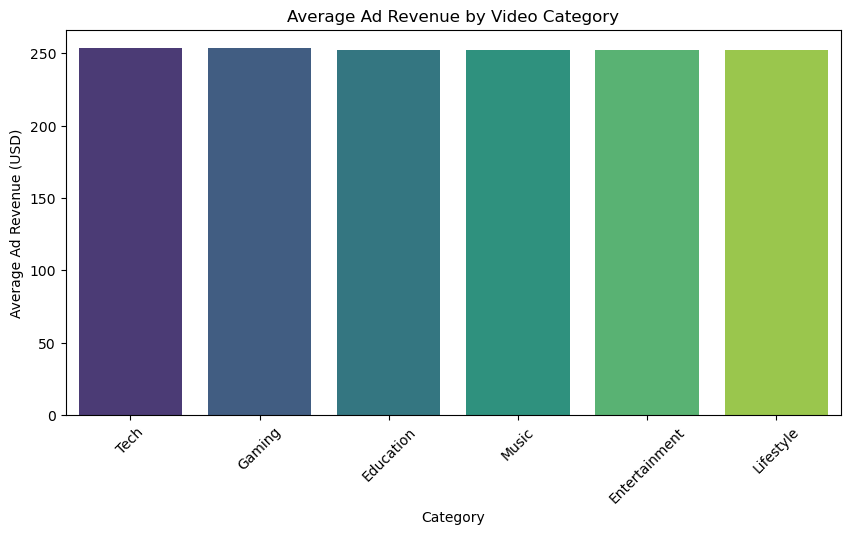

In [9]:
category_revenue = (
    df.groupby("category")["ad_revenue_usd"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values,
    hue=category_revenue.index,
    palette="viridis",
    legend=False
)

plt.title("Average Ad Revenue by Video Category")
plt.xlabel("Category")
plt.ylabel("Average Ad Revenue (USD)")
plt.xticks(rotation=45)

plt.show()

Insight:
Average ad revenue is almost similar across all video categories, around USD 252–USD 254.
Tech has the highest average revenue, but the difference is very small.
Therefore, category alone may not be a strong predictor of ad revenue.

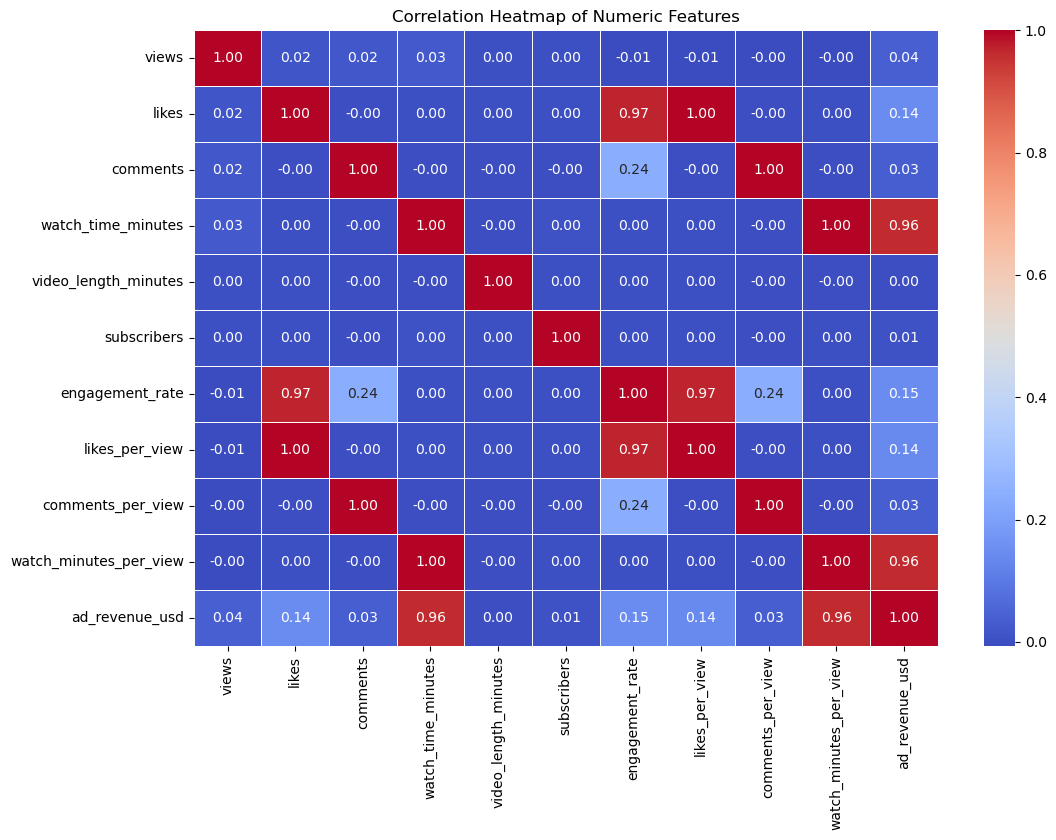

In [10]:
numeric_columns = [
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "engagement_rate",
    "likes_per_view",
    "comments_per_view",
    "watch_minutes_per_view",
    "ad_revenue_usd"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Insight:
Watch time minutes has a very strong positive correlation (0.96) with ad revenue,
making it the most important numeric feature in this dataset. Engagement rate and
likes show weak positive relationships. Views, subscribers, and video length have
very weak direct linear relationships with ad revenue.

The feature watch_minutes_per_view is derived from watch_time_minutes and views.
It is highly redundant with watch_time_minutes, so it will be excluded before
model training to avoid multicollinearity.

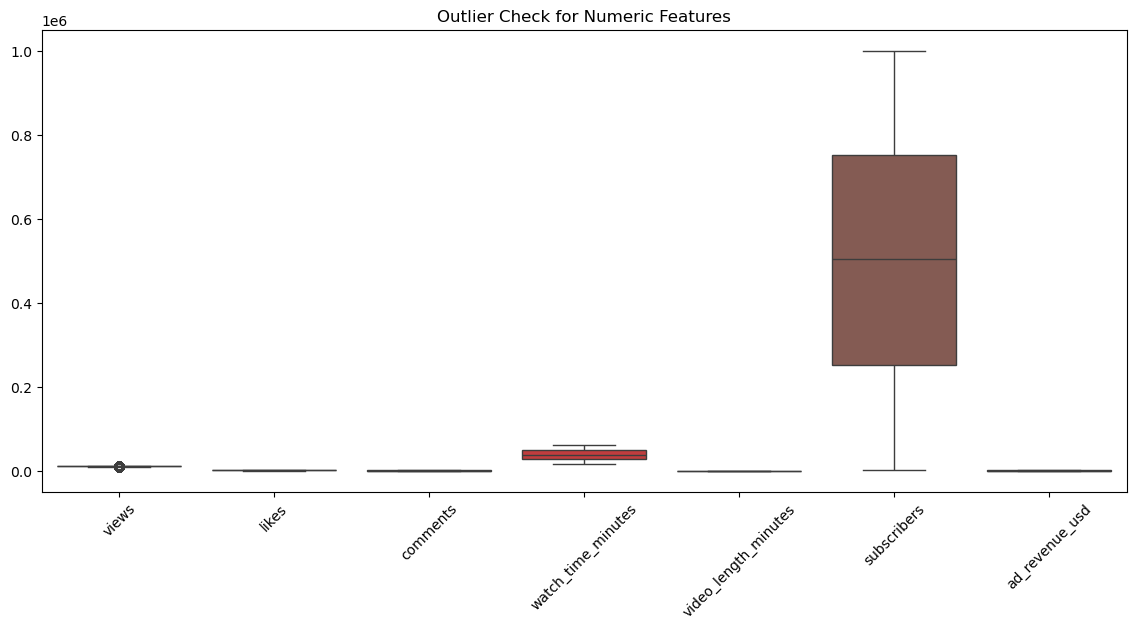

In [11]:
outlier_columns = [
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "ad_revenue_usd"
]

plt.figure(figsize=(14, 6))

sns.boxplot(data=df[outlier_columns])

plt.title("Outlier Check for Numeric Features")
plt.xticks(rotation=45)

plt.show()

Insight:
Subscriber counts have a much larger scale than the other variables, which makes
the combined boxplot difficult to interpret. Potential outliers must be verified
using an IQR-based calculation before applying any treatment. High subscriber
or view counts may represent valid high-performing channels and videos.

In [ ]:
outlier_summary = []

for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_summary.append({
        "column": column,
        "outlier_count": outlier_count,
        "outlier_percentage": round((outlier_count / len(df)) * 100, 2)
    })

outlier_report = pd.DataFrame(outlier_summary)
outlier_report

Insight:
Only the views column contains 0.72% potential outliers. Since unusually high
views can represent legitimate viral videos, these records are retained. No
outliers were detected in the target variable, ad_revenue_usd.

In [13]:
# Columns used to predict ad revenue
feature_columns = [
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "category",
    "device",
    "country",
    "month",
    "day_of_week",
    "engagement_rate"
]

# Input features
X = df[feature_columns]

# Target variable
y = df["ad_revenue_usd"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used for model training:")
print(X.columns.tolist())

X shape: (120000, 12)
y shape: (120000,)

Features used for model training:
['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'month', 'day_of_week', 'engagement_rate']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature data shape:", X_train.shape)
print("Testing feature data shape:", X_test.shape)

print("Training target data shape:", y_train.shape)
print("Testing target data shape:", y_test.shape)

Training feature data shape: (96000, 12)
Testing feature data shape: (24000, 12)
Training target data shape: (96000,)
Testing target data shape: (24000,)


In [15]:
# Numerical columns
numeric_features = [
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "month",
    "engagement_rate"
]

# Text / categorical columns
categorical_features = [
    "category",
    "device",
    "country",
    "day_of_week"
]

# Processing steps for numeric data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Processing steps for categorical data
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [16]:
# Create Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

# Predict ad revenue for test data
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression Results")
print("R² Score:", round(linear_r2, 4))
print("RMSE:", round(linear_rmse, 4))
print("MAE:", round(linear_mae, 4))

Linear Regression Results
R² Score: 0.9526
RMSE: 13.4802
MAE: 3.1188


In [17]:
# Create Ridge Regression pipeline
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

# Train the model
ridge_model.fit(X_train, y_train)

# Predict test data
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate model
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("R² Score:", round(ridge_r2, 4))
print("RMSE:", round(ridge_rmse, 4))
print("MAE:", round(ridge_mae, 4))

Ridge Regression Results
R² Score: 0.9526
RMSE: 13.4799
MAE: 3.1166


In [18]:
# Create Elastic Net pipeline
elastic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))
])

# Train the model
elastic_model.fit(X_train, y_train)

# Predict test data
y_pred_elastic = elastic_model.predict(X_test)

# Evaluate model
elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

print("Elastic Net Regression Results")
print("R² Score:", round(elastic_r2, 4))
print("RMSE:", round(elastic_rmse, 4))
print("MAE:", round(elastic_mae, 4))

Elastic Net Regression Results
R² Score: 0.9526
RMSE: 13.4824
MAE: 3.2313


In [19]:
# Create Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Predict test data
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate model
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results")
print("R² Score:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))
print("MAE:", round(rf_mae, 4))

Random Forest Results
R² Score: 0.95
RMSE: 13.842
MAE: 3.5771


In [20]:
# Create Extra Trees pipeline
extra_trees_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
extra_trees_model.fit(X_train, y_train)

# Predict test data
y_pred_et = extra_trees_model.predict(X_test)

# Evaluate model
et_r2 = r2_score(y_test, y_pred_et)
et_rmse = np.sqrt(mean_squared_error(y_test, y_pred_et))
et_mae = mean_absolute_error(y_test, y_pred_et)

print("Extra Trees Results")
print("R² Score:", round(et_r2, 4))
print("RMSE:", round(et_rmse, 4))
print("MAE:", round(et_mae, 4))

Extra Trees Results
R² Score: 0.9494
RMSE: 13.9272
MAE: 3.6862


In [21]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Elastic Net",
        "Random Forest",
        "Extra Trees"
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        elastic_r2,
        rf_r2,
        et_r2
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        elastic_rmse,
        rf_rmse,
        et_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        elastic_mae,
        rf_mae,
        et_mae
    ]
})

results = results.sort_values(by="RMSE").reset_index(drop=True)

results

,Model,R2 Score,RMSE,MAE
0,Ridge Regression,0.952575,13.479946,3.116607
1,Linear Regression,0.952573,13.480235,3.118845
2,Elastic Net,0.952557,13.482400,3.231254
3,Random Forest,0.949993,13.842008,3.577119
4,Extra Trees,0.949376,13.927156,3.686223


Final Model Selection:
Ridge Regression was selected as the final model because it achieved the lowest
RMSE (13.48) and MAE (3.12), with an R² score of 0.9526. This means the model
explains approximately 95.26% of the variation in YouTube ad revenue.

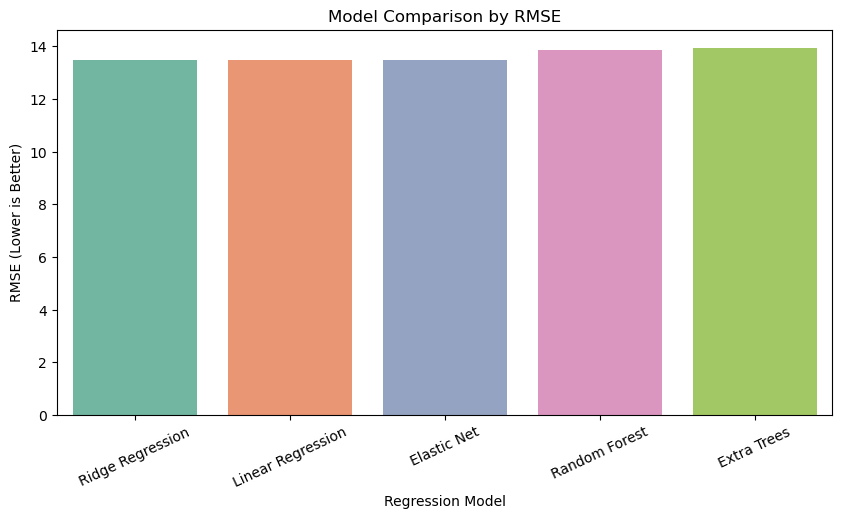

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Regression Model")
plt.ylabel("RMSE (Lower is Better)")
plt.xticks(rotation=25)

plt.show()

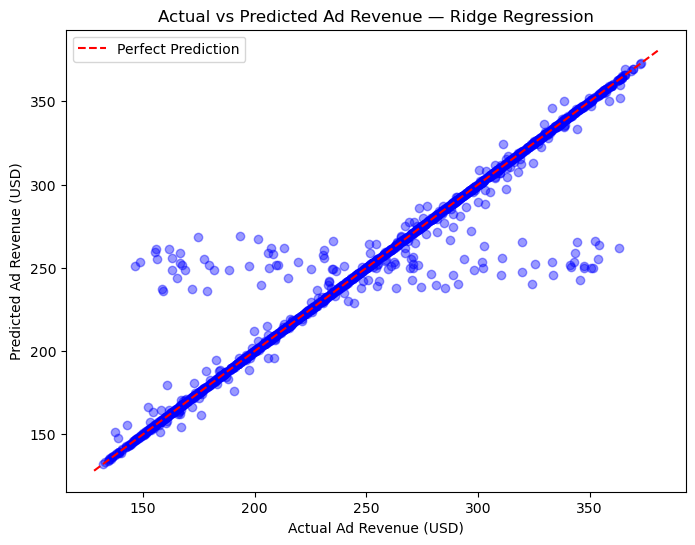

In [23]:
# Ridge model predictions
y_pred_ridge = ridge_model.predict(X_test)

# Use a sample to keep the chart clear
sample_size = 2000
sample_indices = np.random.choice(
    len(y_test),
    size=sample_size,
    replace=False
)

actual_sample = y_test.iloc[sample_indices]
predicted_sample = y_pred_ridge[sample_indices]

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_sample,
    predicted_sample,
    alpha=0.4,
    color="blue"
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Ad Revenue — Ridge Regression")
plt.xlabel("Actual Ad Revenue (USD)")
plt.ylabel("Predicted Ad Revenue (USD)")
plt.legend()

plt.show()

Insight:
Most predicted values lie close to the perfect prediction line, showing that
Ridge Regression predicts ad revenue accurately for most videos. A small number
of records have larger errors, but the overall model fit is strong.

In [24]:
# Get transformed feature names after encoding
feature_names = ridge_model.named_steps["preprocessor"].get_feature_names_out()

# Get Ridge coefficients
coefficients = ridge_model.named_steps["model"].coef_

# Create coefficient table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute coefficient helps identify strongest effects
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Show top 15 influential features
top_features = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).head(15)

top_features

,Feature,Coefficient,Absolute_Coefficient
3,num__watch_time_minutes,59.684930,59.684930
1,num__likes,13.217588,13.217588
7,num__engagement_rate,-4.703437,4.703437
2,num__comments,3.267515,3.267515
0,num__views,0.535323,0.535323
16,cat__device_TV,-0.139302,0.139302
14,cat__device_Desktop,0.096693,0.096693
30,cat__day_of_week_Wednesday,-0.092970,0.092970
21,cat__country_IN,0.086673,0.086673
20,cat__country_DE,-0.083381,0.083381


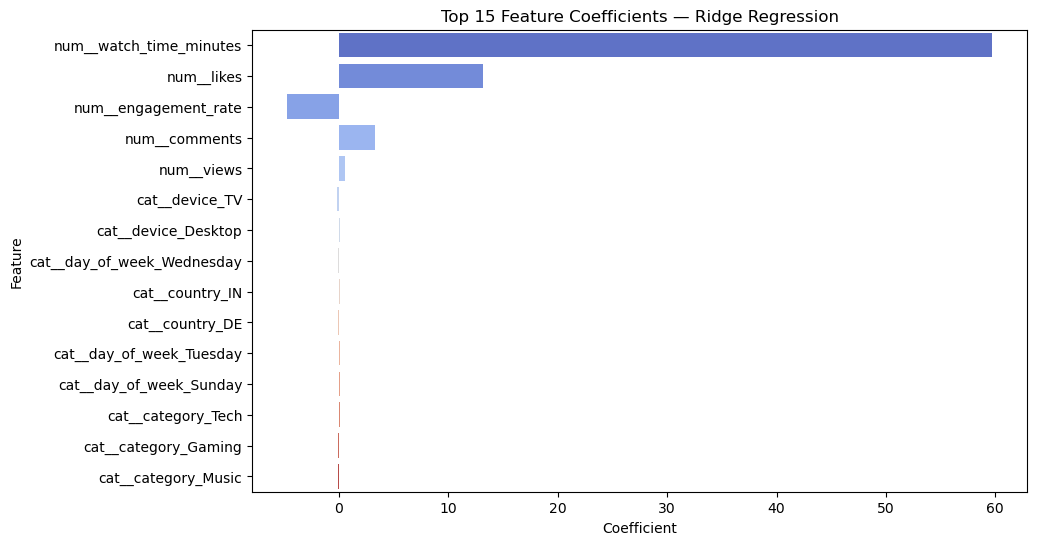

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.title("Top 15 Feature Coefficients — Ridge Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Feature Importance Insight

The Ridge Regression coefficient analysis shows that **watch_time_minutes**
is the strongest predictor of YouTube ad revenue.

- Watch time has a strong positive influence on predicted revenue.
- Likes and comments also have positive contributions.
- Views have a relatively small direct effect in this dataset.
- Category, device, country, and day of week have only minor effects.
- The negative engagement-rate coefficient should be interpreted carefully because
  it is derived from likes, comments, and views, which are already included as
  separate model features.

In [26]:
import joblib

joblib.dump(ridge_model, "ridge_revenue_model.pkl")

print("Ridge model saved successfully!")

Ridge model saved successfully!


In [27]:
# Save cleaned and feature-engineered dataset
df.to_csv("cleaned_youtube_ad_revenue_data.csv", index=False)

# Save all model evaluation results
results.to_csv("model_comparison_results.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Model comparison results saved successfully!")

Cleaned dataset saved successfully!
Model comparison results saved successfully!


# Final Conclusion

This project developed and evaluated machine learning models to predict
YouTube ad revenue using video performance and contextual features.

## Data Preparation
- Removed 2,400 duplicate records.
- Filled missing values in likes, comments, and watch time using median values.
- Created date-based features: month and day of week.
- Created engagement-based features such as engagement rate.
- Retained high-view records because they may represent valid viral videos.

## Model Evaluation
Five regression models were evaluated:

| Model | R² Score | RMSE | MAE |
|---|---:|---:|---:|
| Ridge Regression | 0.9526 | 13.4799 | 3.1166 |
| Linear Regression | 0.9526 | 13.4802 | 3.1188 |
| Elastic Net | 0.9526 | 13.4824 | 3.2313 |
| Random Forest | 0.9500 | 13.8420 | 3.5771 |
| Extra Trees | 0.9494 | 13.9272 | 3.6862 |

## Final Model
Ridge Regression was selected as the final model because it achieved the
lowest RMSE and MAE. The model explains approximately 95.26% of the
variation in YouTube ad revenue.

## Key Business Insights
- Watch time is the strongest predictor of ad revenue.
- Likes and comments have positive contributions to predicted revenue.
- Category, device, country, and day of week have comparatively small effects.
- The trained model can support revenue forecasting and content planning.